# DCGAN on CIFAR-10 - Lab 1: Media generation via DL models

**Goal.** Train a Deep Convolutional GAN (DCGAN) that can generate new 32x32 RGB images that look like CIFAR-10 photos.

**Why DCGAN?** It's the classic convolutional GAN architecture from Radford et al. (2015), and it's still a nice teaching example. The generator is fully convolutional (transposed convs upsample noise into an image), the discriminator is a plain CNN classifier, and the whole thing trains with two Adam optimizers and a binary cross-entropy loss.

**What you'll see in this notebook.**
1. A short theory recap of GANs and what makes DCGAN "deep convolutional".
2. One config cell where every hyperparameter lives, including a `TARGET_CLASS` switch so you can train on a single CIFAR-10 class (fast, cleaner samples) or on all 10 classes.
3. Data loading, model definition, the training loop, loss curves, and a final 8x8 grid of generated images.
4. Saved model weights and sample grids written to disk.


## 1. Theory recap

A GAN consists of two networks playing a minimax game:

* A **generator** $G_{\theta_G}: \mathbb{R}^{n_z} \to \mathbb{R}^{3\times 32\times 32}$ that maps a noise vector $z \sim \mathcal{N}(0, I)$ to an image.
* A **discriminator** $D_{\theta_D}: \mathbb{R}^{3\times 32\times 32} \to (0, 1)$ that estimates the probability that its input is a *real* CIFAR-10 image rather than a fake one from $G$.

They optimise the value function

$$
\min_G \max_D \; V(D, G) \;=\; \mathbb{E}_{x \sim p_\text{data}}[\log D(x)] \;+\; \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))].
$$

In practice we replace the second term for $G$ with the **non-saturating loss** $-\mathbb{E}_z[\log D(G(z))]$ to avoid vanishing gradients early in training. In code this is just two `BCELoss` calls with the right targets.

### What makes a GAN a *DCGAN*?

Radford et al. proposed a few architectural rules of thumb that make convolutional GANs train stably:

* Replace pooling with **strided convolutions** (D) and **fractional-strided / transposed convolutions** (G).
* Use **BatchNorm** in both networks (skip it on the input layer of D and the output layer of G).
* Remove fully-connected hidden layers; the architecture is fully convolutional.
* In the generator, use **ReLU** everywhere except the output, which uses **Tanh** (so outputs lie in $[-1, 1]$, matching the normalised real images).
* In the discriminator, use **LeakyReLU(0.2)** everywhere.
* Adam with $\text{lr}=2\times 10^{-4}$ and $\beta_1=0.5$.

We follow these rules below.


## 2. Imports, device and seeds


In [1]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torchvision.utils as vutils
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cpu


## 3. Hyperparameters

Everything you'd want to tweak lives in the cell below.

* **`TARGET_CLASS`**: set this to one of the ten CIFAR-10 class names to train on a single class only (faster, much cleaner samples on CPU). Set it to `None` to train on the full 50,000-image training set.
* **`EPOCHS`**: 30 epochs on a single class is enough to see recognisable shapes on CPU. Bump up to 80-150 on a GPU for sharper results.
* **`NZ` / `NGF` / `NDF`**: latent vector size and feature-map widths. The DCGAN paper defaults work well.


In [2]:
TARGET_CLASS = "horse"

IMAGE_SIZE = 32
NC = 3
NZ = 100
NGF = 64
NDF = 64

BATCH_SIZE = 128
EPOCHS = 30
LR = 2e-4
BETA1 = 0.5
BETA2 = 0.999

REAL_LABEL = 0.9
FAKE_LABEL = 0.0

DATA_DIR = Path("data")
SAMPLES_DIR = Path("samples")
CHECKPOINT_DIR = Path("checkpoints")
for d in (DATA_DIR, SAMPLES_DIR, CHECKPOINT_DIR):
    d.mkdir(parents=True, exist_ok=True)

CIFAR10_CLASSES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)
if TARGET_CLASS is not None:
    assert TARGET_CLASS in CIFAR10_CLASSES, f"Unknown class {TARGET_CLASS!r}"
    print(f"Training on a single class: {TARGET_CLASS!r}")
else:
    print("Training on all 10 CIFAR-10 classes")


Training on a single class: 'horse'


## 4. Dataset

We download CIFAR-10 with `torchvision`, normalise pixel values to $[-1, 1]$ (so they match the generator's `Tanh` output), and, if `TARGET_CLASS` is set, take a `Subset` containing only the images of that class.


In [3]:
transform = T.Compose([
    T.Resize(IMAGE_SIZE),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_dataset = torchvision.datasets.CIFAR10(
    root=str(DATA_DIR), train=True, download=True, transform=transform
)

if TARGET_CLASS is not None:
    target_idx = CIFAR10_CLASSES.index(TARGET_CLASS)
    indices = [i for i, t in enumerate(full_dataset.targets) if t == target_idx]
    dataset = Subset(full_dataset, indices)
else:
    dataset = full_dataset

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    drop_last=True,
)

print(f"Dataset size: {len(dataset)} images")
print(f"Batches per epoch: {len(dataloader)}")


100%|████████████████████████████████████| 170M/170M [00:28<00:00, 5.91MB/s]
C:\Users\Smart\Desktop\dl_model_lab_1\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Dataset size: 5000 images
Batches per epoch: 39


### Peek at a batch of real images


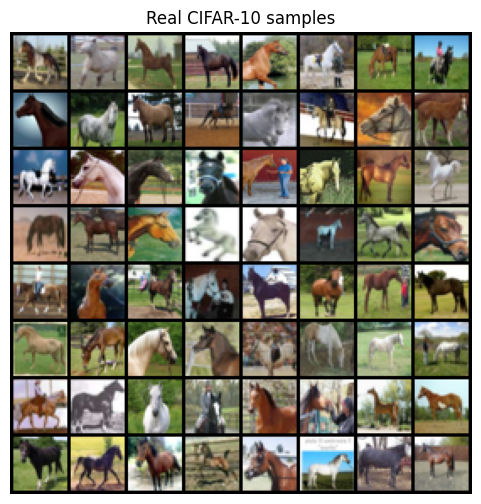

In [4]:
real_batch, _ = next(iter(dataloader))
grid = vutils.make_grid(real_batch[:64], nrow=8, normalize=True, value_range=(-1, 1))

plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Real CIFAR-10 samples")
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.show()


## 5. Generator

The generator turns a $z \in \mathbb{R}^{100}$ noise vector into a $3 \times 32 \times 32$ image through four transposed-convolution blocks:

$$
\underbrace{1\times 1}_{n_z} \;\to\; \underbrace{4\times 4}_{8\,n_{gf}} \;\to\; \underbrace{8\times 8}_{4\,n_{gf}} \;\to\; \underbrace{16\times 16}_{2\,n_{gf}} \;\to\; \underbrace{32\times 32}_{3}.
$$

Each intermediate block is `ConvTranspose2d -> BatchNorm2d -> ReLU`. The final block is `ConvTranspose2d -> Tanh` (no BN on the output).


In [5]:
class Generator(nn.Module):
    def __init__(self, nz: int = NZ, ngf: int = NGF, nc: int = NC):
        super().__init__()
        self.main = nn.Sequential(
            # z: (B, nz, 1, 1) -> (B, 8*ngf, 4, 4)
            nn.ConvTranspose2d(nz, ngf * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # (B, 8*ngf, 4, 4) -> (B, 4*ngf, 8, 8)
            nn.ConvTranspose2d(ngf * 8, ngf * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # (B, 4*ngf, 8, 8) -> (B, 2*ngf, 16, 16)
            nn.ConvTranspose2d(ngf * 4, ngf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # (B, 2*ngf, 16, 16) -> (B, nc, 32, 32)
            nn.ConvTranspose2d(ngf * 2, nc, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.main(z)


## 6. Discriminator

The discriminator is the mirror image: four strided convolutions that halve the spatial size each time, with `LeakyReLU(0.2)` activations and `BatchNorm2d` on every block except the input. It ends in a single scalar logit, then a `Sigmoid`.


In [6]:
class Discriminator(nn.Module):
    def __init__(self, nc: int = NC, ndf: int = NDF):
        super().__init__()
        self.main = nn.Sequential(
            # (B, nc, 32, 32) -> (B, ndf, 16, 16)
            nn.Conv2d(nc, ndf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (B, ndf, 16, 16) -> (B, 2*ndf, 8, 8)
            nn.Conv2d(ndf, ndf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (B, 2*ndf, 8, 8) -> (B, 4*ndf, 4, 4)
            nn.Conv2d(ndf * 2, ndf * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (B, 4*ndf, 4, 4) -> (B, 1, 1, 1)
            nn.Conv2d(ndf * 4, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.main(x).view(-1)


## 7. Weight initialisation

The DCGAN paper initialises all conv weights from $\mathcal{N}(0, 0.02^2)$ and BatchNorm weights from $\mathcal{N}(1, 0.02^2)$ with zero biases. We apply that scheme below.


In [7]:
def dcgan_weights_init(module: nn.Module) -> None:
    classname = module.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0.0)


G = Generator().to(device)
D = Discriminator().to(device)
G.apply(dcgan_weights_init)
D.apply(dcgan_weights_init)

n_params_g = sum(p.numel() for p in G.parameters())
n_params_d = sum(p.numel() for p in D.parameters())
print(f"Generator parameters    : {n_params_g:,}")
print(f"Discriminator parameters: {n_params_d:,}")


Generator parameters    : 3,448,576
Discriminator parameters: 663,296


## 8. Training loop

Per minibatch we do three things:

1. **Train D on real images**: push $D(x)$ towards `REAL_LABEL` (0.9, with mild label smoothing).
2. **Train D on fake images**: push $D(G(z))$ towards `FAKE_LABEL` (0.0).
3. **Train G**: push $D(G(z))$ towards `REAL_LABEL` (the non-saturating generator loss).

We keep a fixed `fixed_noise` tensor so that the saved sample grids show how the *same* latent vectors evolve over training.


In [8]:
criterion = nn.BCELoss()
opt_g = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, BETA2))
opt_d = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, BETA2))

fixed_noise = torch.randn(64, NZ, 1, 1, device=device)

g_losses: list[float] = []
d_losses: list[float] = []
img_history: list[torch.Tensor] = []

for epoch in range(1, EPOCHS + 1):
    epoch_g, epoch_d, n_batches = 0.0, 0.0, 0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    for real, _ in pbar:
        real = real.to(device, non_blocking=True)
        bsz = real.size(0)

        # 1) Discriminator update
        D.zero_grad(set_to_none=True)
        labels_real = torch.full((bsz,), REAL_LABEL, device=device)
        out_real = D(real)
        loss_d_real = criterion(out_real, labels_real)
        loss_d_real.backward()

        noise = torch.randn(bsz, NZ, 1, 1, device=device)
        fake = G(noise)
        labels_fake = torch.full((bsz,), FAKE_LABEL, device=device)
        out_fake = D(fake.detach())
        loss_d_fake = criterion(out_fake, labels_fake)
        loss_d_fake.backward()

        loss_d = loss_d_real + loss_d_fake
        opt_d.step()

        # 2) Generator update (non-saturating loss)
        G.zero_grad(set_to_none=True)
        out_fake_for_g = D(fake)
        loss_g = criterion(out_fake_for_g, labels_real)
        loss_g.backward()
        opt_g.step()

        epoch_d += loss_d.item()
        epoch_g += loss_g.item()
        n_batches += 1
        pbar.set_postfix(d=f"{loss_d.item():.3f}", g=f"{loss_g.item():.3f}")

    g_losses.append(epoch_g / n_batches)
    d_losses.append(epoch_d / n_batches)

    G.eval()
    with torch.no_grad():
        fake_grid = vutils.make_grid(G(fixed_noise).cpu(), nrow=8, normalize=True, value_range=(-1, 1))
    G.train()
    img_history.append(fake_grid)
    vutils.save_image(fake_grid, SAMPLES_DIR / f"epoch_{epoch:03d}.png")

    print(f"Epoch {epoch:3d} | D loss {d_losses[-1]:.4f} | G loss {g_losses[-1]:.4f}")


Epoch 1/30:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch   1 | D loss 1.2329 | G loss 4.4928


Epoch 2/30:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch   2 | D loss 0.5796 | G loss 4.9139


Epoch 3/30:   0%|          | 0/39 [00:00<?, ?it/s]

...

Epoch  28 | D loss 0.6815 | G loss 2.3747


Epoch 29/30:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch  29 | D loss 0.7657 | G loss 2.3700


Epoch 30/30:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch  30 | D loss 1.0781 | G loss 2.2664


## 9. Loss curves

Healthy DCGAN training looks *noisy but bounded*: D loss stays away from 0, and G loss stays away from infinity. If D loss collapses to 0, the discriminator has won and the generator stops learning. In that case, try lowering D's learning rate, adding noise to the inputs, or training G twice per D step.


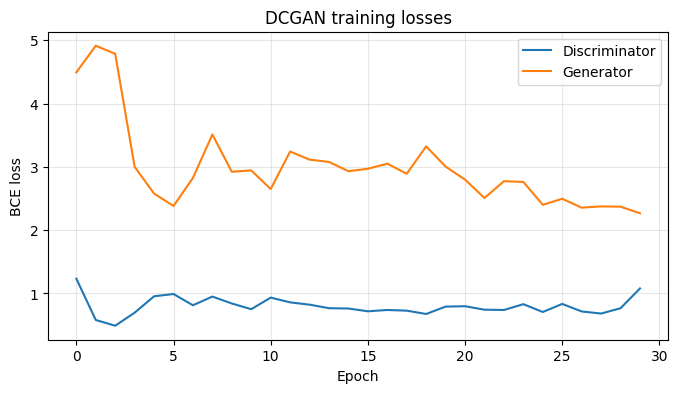

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(d_losses, label="Discriminator")
plt.plot(g_losses, label="Generator")
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("DCGAN training losses")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 10. Final generated samples


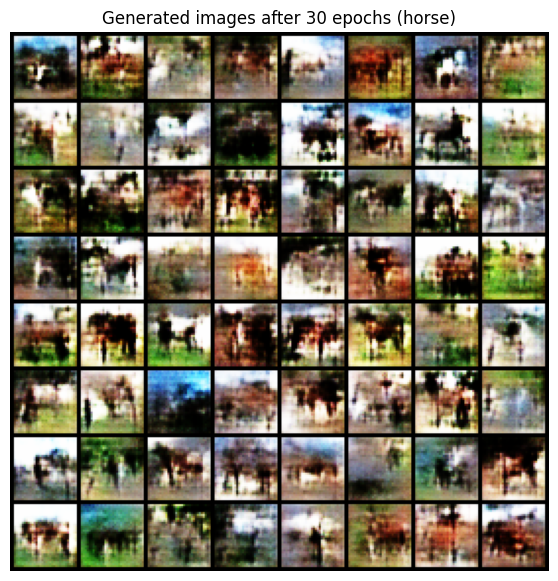

In [10]:
G.eval()
with torch.no_grad():
    final_noise = torch.randn(64, NZ, 1, 1, device=device)
    final_fakes = G(final_noise).cpu()

final_grid = vutils.make_grid(final_fakes, nrow=8, normalize=True, value_range=(-1, 1))
vutils.save_image(final_grid, SAMPLES_DIR / "final.png")

title_suffix = TARGET_CLASS if TARGET_CLASS is not None else "all classes"
plt.figure(figsize=(7, 7))
plt.axis("off")
plt.title(f"Generated images after {EPOCHS} epochs ({title_suffix})")
plt.imshow(final_grid.permute(1, 2, 0).numpy())
plt.show()


## 11. Save model checkpoints


In [11]:
torch.save(G.state_dict(), CHECKPOINT_DIR / "generator.pt")
torch.save(D.state_dict(), CHECKPOINT_DIR / "discriminator.pt")
print("Saved model weights to:", CHECKPOINT_DIR.resolve())
print("Saved sample grids to :", SAMPLES_DIR.resolve())


Saved model weights to: C:\Users\Smart\Desktop\dl_model_lab_1\checkpoints
Saved sample grids to : C:\Users\Smart\Desktop\dl_model_lab_1\samples


## 12. Conclusion

With the default settings (`TARGET_CLASS="horse"`, 30 epochs), we see the following:

* The generator quickly picks up the dominant colour palette of the class (greens and browns for `horse`).
* By epoch ~10 you can usually make out coarse silhouettes. By epoch 30 the samples have plausible shape and texture, but they're clearly low resolution.
* The two losses oscillate around stable values, which is what you want. A monotonically falling D loss usually means mode collapse.